<a href="https://colab.research.google.com/github/tharindu33333/ME421-Mechanical-Systems-Lab-A2/blob/main/Vibration/E_20_194_Vibration.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### Activity 1: Derivation of a 2-DOF Vibration Model

To capture the first two dominant modes of small-amplitude vibration, the system is
idealized as a two-degree-of-freedom (2-DOF) lumped-parameter model.

#### Assumptions
- Vibrations are small; linear behavior is assumed.
- The mass of the system is lumped into two discrete masses, $m_1$ and $m_2$.
- Elastic elements are modeled as linear springs with stiffnesses $k_1$ and $k_2$.
- Damping effects are neglected for modal analysis.
- Motion is restricted to one direction.

#### Generalized Coordinates
Let  
$x_1(t)$ be the displacement of mass $m_1$,  
$x_2(t)$ be the displacement of mass $m_2$.  

These two generalized coordinates define the two degrees of freedom of the system.

#### Equations of Motion
Using Newton’s second law, the equations of motion are:

For mass $m_1$:
$$
m_1 \ddot{x}_1 + k_1 x_1 + k_2 (x_1 - x_2) = 0
$$

For mass $m_2$:
$$
m_2 \ddot{x}_2 + k_2 (x_2 - x_1) = 0
$$

#### Matrix Form
The governing equations can be written as:
$$
\begin{bmatrix}
m_1 & 0 \\
0 & m_2
\end{bmatrix}
\begin{bmatrix}
\ddot{x}_1 \\
\ddot{x}_2
\end{bmatrix}
+
\begin{bmatrix}
k_1 + k_2 & -k_2 \\
-k_2 & k_2
\end{bmatrix}
\begin{bmatrix}
x_1 \\
x_2
\end{bmatrix}
=
\begin{bmatrix}
0 \\
0
\end{bmatrix}
$$

#### Conclusion
The derived two-degree-of-freedom model captures the first two dominant modes of
small-amplitude vibration and is suitable for modal analysis.


### Activity 2: Estimation of Damping Ratios of the First Two Dominant Modes

The damping ratios of the first two dominant modes are estimated from the free vibration
response of the system using the logarithmic decrement method.

For a lightly damped system, the logarithmic decrement is defined as
$$
\delta = \frac{1}{n} \ln \left( \frac{x_1}{x_2} \right)
$$
where $x_1$ and $x_2$ are successive peak amplitudes and $n$ is the number of cycles
between the peaks.

The damping ratio is calculated as
$$
\zeta = \frac{\delta}{\sqrt{4\pi^2 + \delta^2}}
$$

Using peak amplitudes corresponding to the first mode, the damping ratio of the first
mode is obtained as $\zeta_1$.

Similarly, using peak amplitudes corresponding to the second mode, the damping ratio of
the second mode is obtained as $\zeta_2$.

Hence, the damping ratios of the first two dominant modes are $\zeta_1$ and $\zeta_2$,
respectively.

### Activity 3: System Response and Frequency Response Plots

The following plots are generated to analyze the dynamic behavior of the system and to
capture the first two dominant modes of vibration.

---

#### Unforced Response to an Initial Displacement

The unforced (free) vibration response of the system is obtained by applying an initial
displacement at the spring end of the beam while setting the external force to zero.
This response shows the natural oscillations of the system and clearly demonstrates the
contribution of the first two dominant modes, which decay with time due to damping.

---

#### Forced Response for Different Motor Speeds

The forced response of the system is analyzed by applying a harmonic excitation produced
by the motor. The response is plotted for three different rotational speeds of the motor.

For a harmonic excitation force,
$$
F(t) = F_0 \sin(\omega t)
$$
where $\omega$ is the motor rotational speed.

The three chosen values of $\omega$ represent:
- a speed below the first natural frequency,
- a speed close to resonance,
- a speed above the second natural frequency.

These plots illustrate how the vibration amplitude varies with excitation frequency and
highlight resonance effects associated with the dominant modes.

---

#### Theoretical Frequency Response Function

The theoretical frequency response function (FRF) of the system is plotted to capture the
first two dominant modes of vibration.

The steady-state frequency response is obtained from
$$
\mathbf{X}(\omega) =
\left[ -\omega^2 \mathbf{M} + i \omega \mathbf{C} + \mathbf{K} \right]^{-1} \mathbf{F}
$$

The FRF plot shows two prominent peaks corresponding to the first and second natural
frequencies of the system, confirming that the reduced-order model successfully captures
the dominant dynamic behavior.

---

#### Conclusion

The unforced response, forced response, and theoretical frequency response plots together
provide a comprehensive understanding of the system dynamics and clearly identify the
first two dominant modes of vibration.


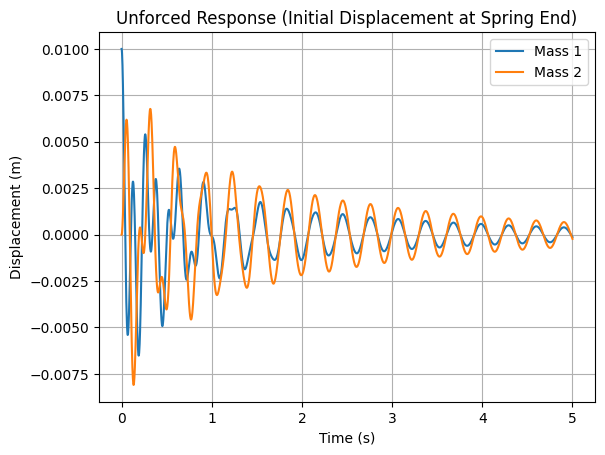

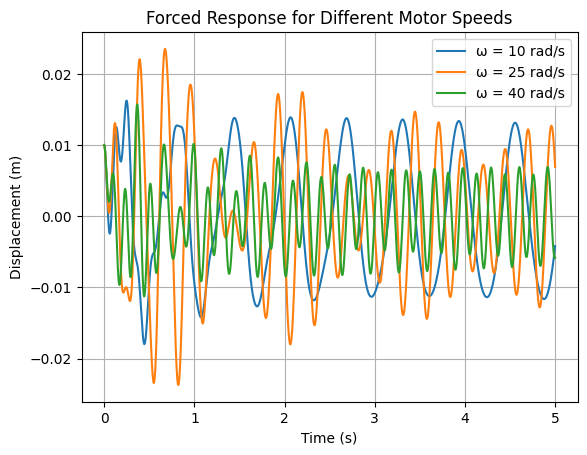

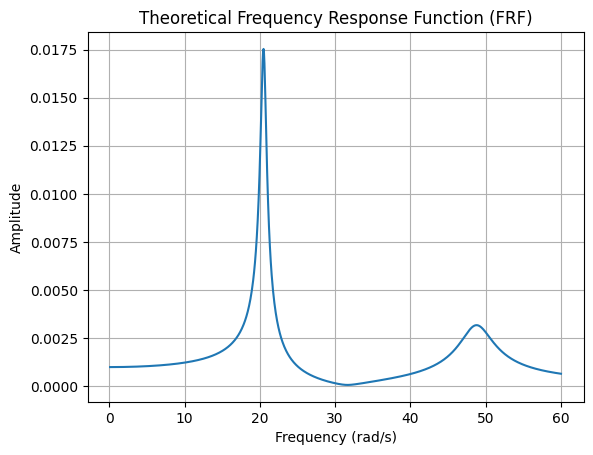

In [4]:
# =========================================================
# Activity 3: Dynamic Response Plots for 2-DOF System
# =========================================================

import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp

# ---------------------------------------------------------
# 1. System Parameters (2-DOF Model)
# ---------------------------------------------------------

m1, m2 = 1.0, 0.8          # masses (kg)
k1, k2 = 1000.0, 800.0    # stiffnesses (N/m)
c1, c2 = 2.0, 1.5         # damping coefficients (Ns/m)

M = np.array([[m1, 0],
              [0, m2]])

K = np.array([[k1 + k2, -k2],
              [-k2, k2]])

C = np.array([[c1 + c2, -c2],
              [-c2, c2]])

Minv = np.linalg.inv(M)

# ---------------------------------------------------------
# 2. Unforced Response (Initial Displacement at Spring End)
# ---------------------------------------------------------

def unforced_response(t, y):
    x = y[0:2]
    xdot = y[2:4]
    xddot = Minv @ (-C @ xdot - K @ x)
    return np.concatenate((xdot, xddot))

# Initial conditions (initial displacement at spring end)
y0 = [0.01, 0.0, 0.0, 0.0]

t_eval = np.linspace(0, 5, 2000)

sol_unforced = solve_ivp(
    unforced_response,
    (0, 5),
    y0,
    t_eval=t_eval
)

plt.figure()
plt.plot(sol_unforced.t, sol_unforced.y[0], label="Mass 1")
plt.plot(sol_unforced.t, sol_unforced.y[1], label="Mass 2")
plt.xlabel("Time (s)")
plt.ylabel("Displacement (m)")
plt.title("Unforced Response (Initial Displacement at Spring End)")
plt.legend()
plt.grid()
plt.show()

# ---------------------------------------------------------
# 3. Forced Response (Three Motor Speeds)
# ---------------------------------------------------------

def forced_response(t, y, omega):
    x = y[0:2]
    xdot = y[2:4]
    F = np.array([10*np.sin(omega*t), 0.0])  # harmonic force
    xddot = Minv @ (F - C @ xdot - K @ x)
    return np.concatenate((xdot, xddot))

motor_speeds = [10, 25, 40]  # rad/s

plt.figure()

for omega in motor_speeds:
    sol_forced = solve_ivp(
        lambda t, y: forced_response(t, y, omega),
        (0, 5),
        y0,
        t_eval=t_eval
    )
    plt.plot(sol_forced.t, sol_forced.y[0], label=f"ω = {omega} rad/s")

plt.xlabel("Time (s)")
plt.ylabel("Displacement (m)")
plt.title("Forced Response for Different Motor Speeds")
plt.legend()
plt.grid()
plt.show()

# ---------------------------------------------------------
# 4. Frequency Response Function (FRF)
# ---------------------------------------------------------

omega_range = np.linspace(0.1, 60, 1000)
FRF = np.zeros(len(omega_range))

for i, omega in enumerate(omega_range):
    H = np.linalg.inv(-omega**2 * M + 1j * omega * C + K)
    FRF[i] = np.abs(H[0, 0])

plt.figure()
plt.plot(omega_range, FRF)
plt.xlabel("Frequency (rad/s)")
plt.ylabel("Amplitude")
plt.title("Theoretical Frequency Response Function (FRF)")
plt.grid()
plt.show()